In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Data load
X_train = np.load('../data/processed/X_tr_smote.npy')
y_train = np.load('../data/processed/y_tr_smote.npy')
X_val   = np.load('../data/processed/X_val.npy')
y_val   = np.load('../data/processed/y_val.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_test  = np.load('../data/processed/y_test.npy')

print(f"X_train: {X_train.shape}")
print(f"X_val  : {X_val.shape}")
print(f"X_test : {X_test.shape}")

X_train: (1872, 195)
X_val  : (251, 195)
X_test : (314, 195)


In [3]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve
import numpy as np

# Base models
base_models = [
    ('lr', LogisticRegression(
        C=1.0,
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    )),
    ('rf', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )),
    ('xgb', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ))
]

# Meta model
meta_model = LogisticRegression(
    class_weight='balanced',
    random_state=42
)

# Stacking
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1,
    passthrough=False
)

print(" Stacking model ready!")

 Stacking model ready!


In [4]:
# Train
print("Training stacking model...")
stack_model.fit(X_train, y_train)


# Predictions
y_proba_stack = stack_model.predict_proba(X_test)[:, 1]

# Threshold tuning
p, r, t = precision_recall_curve(y_test, y_proba_stack)
f1 = 2*(p[:-1]*r[:-1])/(p[:-1]+r[:-1]+1e-8)
best_t = t[np.argmax(f1)]
y_pred_stack = (y_proba_stack >= best_t).astype(int)

print(f"\nOptimal Threshold: {best_t:.3f}")
print(classification_report(y_test, y_pred_stack,
      target_names=['PASS(0)', 'FAIL(1)']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_stack):.4f}")

Training stacking model...

Optimal Threshold: 0.003
              precision    recall  f1-score   support

     PASS(0)       0.97      0.75      0.85       293
     FAIL(1)       0.16      0.67      0.26        21

    accuracy                           0.75       314
   macro avg       0.57      0.71      0.56       314
weighted avg       0.92      0.75      0.81       314

ROC-AUC: 0.7609


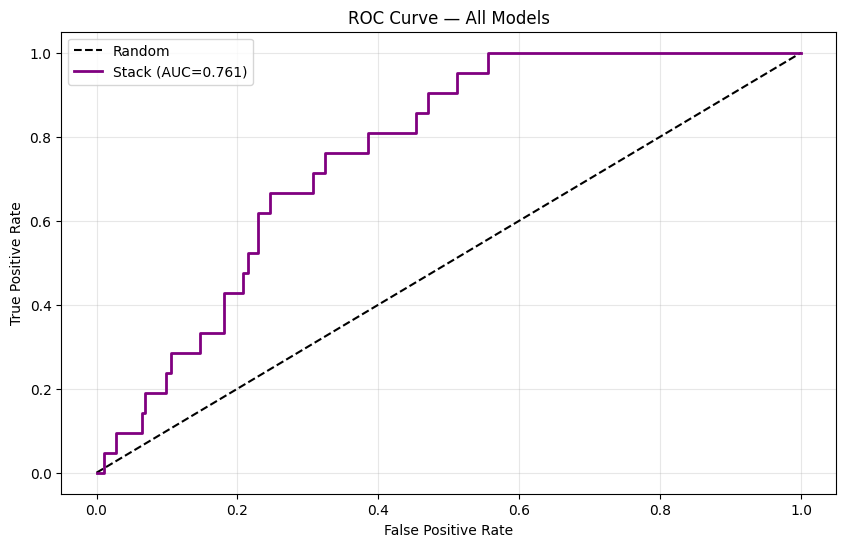

In [6]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_s, tpr_s, _ = roc_curve(y_test, y_proba_stack)

plt.figure(figsize=(10, 6))
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.plot(fpr_s, tpr_s, color='purple',
         linewidth=2,
         label=f'Stack (AUC=0.761)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Models')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<h1>Optuna</h1>

In [8]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int(
            'n_estimators', 100, 500),
        'max_depth': trial.suggest_int(
            'max_depth', 3, 9),
        'learning_rate': trial.suggest_float(
            'learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float(
            'subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float(
            'colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'eval_metric': 'logloss',
        'verbosity': 0
    }

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_proba)

# 50 trials
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Best AUC   : {study.best_value:.4f}")
print(f"Best Params: {study.best_params}")

Best AUC   : 0.6951
Best Params: {'n_estimators': 360, 'max_depth': 9, 'learning_rate': 0.28825215423761075, 'subsample': 0.7362470102617409, 'colsample_bytree': 0.9104321403152649}


In [9]:
# Best params
best_xgb_optuna = XGBClassifier(
    **study.best_params,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

best_xgb_optuna.fit(X_train, y_train)

y_proba_optuna = best_xgb_optuna.predict_proba(
    X_test)[:, 1]

p, r, t = precision_recall_curve(
    y_test, y_proba_optuna)
f1 = 2*(p[:-1]*r[:-1])/(p[:-1]+r[:-1]+1e-8)
best_t = t[np.argmax(f1)]
y_pred_optuna = (y_proba_optuna >= best_t).astype(int)

print(f"Threshold: {best_t:.3f}")
print(classification_report(y_test, y_pred_optuna,
      target_names=['PASS(0)', 'FAIL(1)']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_optuna):.4f}")

Threshold: 0.050
              precision    recall  f1-score   support

     PASS(0)       0.96      0.91      0.94       293
     FAIL(1)       0.28      0.48      0.35        21

    accuracy                           0.88       314
   macro avg       0.62      0.69      0.64       314
weighted avg       0.91      0.88      0.90       314

ROC-AUC: 0.7323


In [11]:
import shap

# RF model pe SHAP lagao
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# SHAP explainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Feature names
import pandas as pd
feature_names = pd.read_csv(
    '../data/processed/secom_features.csv'
).columns[:-1].tolist()

print(f"SHAP values shape: {shap_values.shape}")


SHAP values shape: (314, 195, 2)


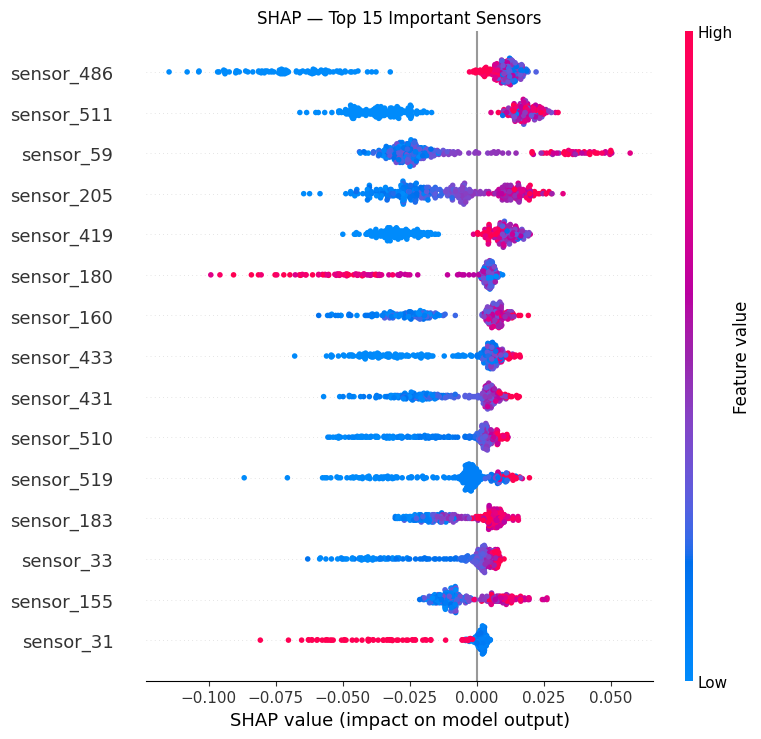

In [13]:
# FAIL class ke SHAP values 
shap_fail = shap_values[:, :, 1]


plt.figure()
shap.summary_plot(
    shap_fail,
    X_test,
    feature_names=feature_names,
    max_display=15,
    show=False
)
plt.title("SHAP — Top 15 Important Sensors")
plt.tight_layout()

plt.show()


In [14]:
""" sensor_486 → 
Red dots right → High value = FAIL risk! 
Blue dots left → Low value = PASS safe

sensor_511 →
Similar pattern!

sensor_59  →
Red right → Zyada active = FAIL!
(Feature importance mein bhi top tha!)

sensor_205 →
Mixed pattern

sensor_419 →
Blue dots right → Low value = FAIL risk!
"""

' sensor_486 → \nRed dots right → High value = FAIL risk! \nBlue dots left → Low value = PASS safe\n\nsensor_511 →\nSimilar pattern!\n\nsensor_59  →\nRed right → Zyada active = FAIL!\n(Feature importance mein bhi top tha!)\n\nsensor_205 →\nMixed pattern\n\nsensor_419 →\nBlue dots right → Low value = FAIL risk!\n'

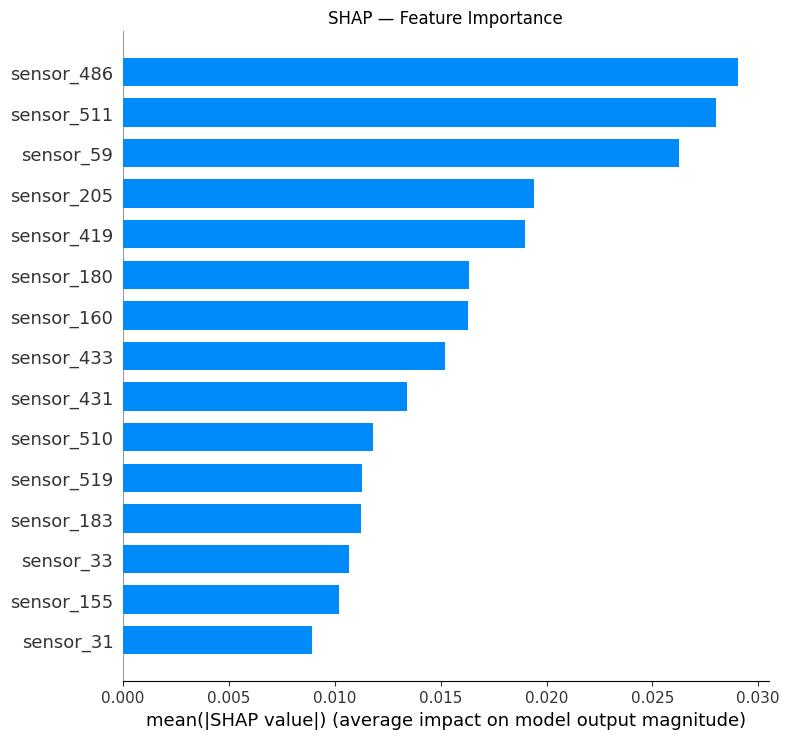

In [15]:
# Mean SHAP values — bar plot
shap.summary_plot(
    shap_fail,
    X_test,
    feature_names=feature_names,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title("SHAP — Feature Importance")
plt.tight_layout()

plt.show()

In [16]:
import lime
import lime.lime_tabular
import numpy as np

# LIME Explainer
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train,
    feature_names=feature_names,
    class_names=['PASS(0)', 'FAIL(1)'],
    mode='classification'
)

# find a FAIL sample from test set
fail_indices = np.where(y_test == 1)[0]
sample_idx = fail_indices[0]
sample = X_test[sample_idx]

print(f"Sample index : {sample_idx}")
print(f"Actual label : {'FAIL' if y_test[sample_idx]==1 else 'PASS'}")
print(f"Model predict: {rf_model.predict([sample])[0]}")

Sample index : 37
Actual label : FAIL
Model predict: 0


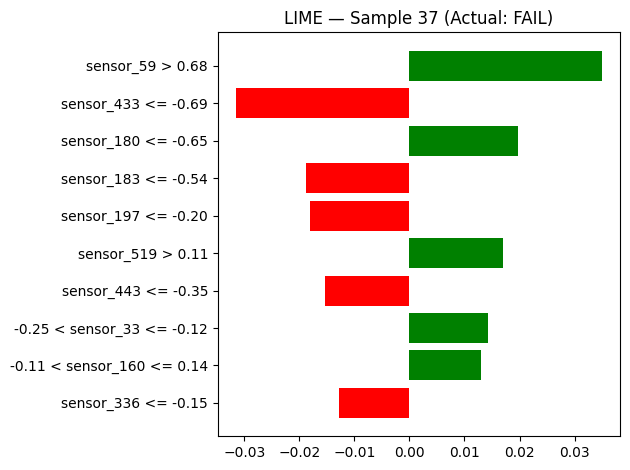


Top 10 Features:
  sensor_59 > 0.68: 0.0349
  sensor_433 <= -0.69: -0.0315
  sensor_180 <= -0.65: 0.0198
  sensor_183 <= -0.54: -0.0187
  sensor_197 <= -0.20: -0.0180
  sensor_519 > 0.11: 0.0169
  sensor_443 <= -0.35: -0.0154
  -0.25 < sensor_33 <= -0.12: 0.0143
  -0.11 < sensor_160 <= 0.14: 0.0129
  sensor_336 <= -0.15: -0.0129


In [18]:
# LIME explanation
exp = explainer_lime.explain_instance(
    sample,
    rf_model.predict_proba,
    num_features=10
)

# Plot
fig = exp.as_pyplot_figure()
plt.title(f"LIME — Sample {sample_idx} (Actual: FAIL)")
plt.tight_layout()

plt.show()

# Text explanation
print("\nTop 10 Features:")
for feat, weight in exp.as_list():
    print(f"  {feat}: {weight:.4f}")

In [23]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("SECOM_Defect_Detection")


# LR 
with mlflow.start_run(run_name="Logistic_Regression"):
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_metric("auc", 0.664)
    mlflow.log_metric("fail_recall", 0.43)
    mlflow.log_metric("fail_f1", 0.23)

# RF 
with mlflow.start_run(run_name="Random_Forest"):
    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 10)
    mlflow.log_metric("auc", 0.789)
    mlflow.log_metric("fail_recall", 0.43)
    mlflow.log_metric("fail_f1", 0.30)
    mlflow.sklearn.log_model(rf_model, "model")

# XGB 
with mlflow.start_run(run_name="XGBoost_Tuned"):
    mlflow.log_param("model", "XGBoost")
    mlflow.log_metric("auc", 0.742)
    mlflow.log_metric("fail_recall", 0.57)
    mlflow.log_metric("fail_f1", 0.34)

# Stacking 
with mlflow.start_run(run_name="Stacking"):
    mlflow.log_param("model", "Stacking")
    mlflow.log_param("base_models", "LR+RF+XGB")
    mlflow.log_metric("auc", 0.761)
    mlflow.log_metric("fail_recall", 0.67)
    mlflow.log_metric("fail_f1", 0.26)
    mlflow.sklearn.log_model(
    stack_model, 
    "model",
    skops_trusted_types=[
        'sklearn.utils._bunch.Bunch',
        'xgboost.core.Booster',
        'xgboost.sklearn.XGBClassifier'
    ]
)

print("Experiement tested")

2026/07/22 22:34:50 INFO mlflow.tracking.fluent: Experiment with name 'SECOM_Defect_Detection' does not exist. Creating a new experiment.
2026/07/22 22:34:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/22 22:35:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Experiement tested


In [25]:
import mlflow
import os


db_path = os.path.abspath('../mlflow.db')
mlflow.set_tracking_uri(f"sqlite:///{db_path}")
mlflow.set_experiment("SECOM_Defect_Detection")

with mlflow.start_run(run_name="Test2"):
    mlflow.log_metric("auc", 0.789)

print(f"DB Path: {db_path}")
print("Done")

2026/07/22 23:01:03 INFO mlflow.tracking.fluent: Experiment with name 'SECOM_Defect_Detection' does not exist. Creating a new experiment.


DB Path: c:\Users\Jatin\OneDrive\Desktop\DL projects\3. Gyaani Project (Ultimate Revision)\secom\mlflow.db
Done


In [26]:
import mlflow
import os

db_path = os.path.abspath('../mlflow.db')
mlflow.set_tracking_uri(f"sqlite:///{db_path}")
mlflow.set_experiment("SECOM_Defect_Detection")

with mlflow.start_run(run_name="Logistic_Regression"):
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_metric("auc", 0.664)
    mlflow.log_metric("fail_recall", 0.43)
    mlflow.log_metric("fail_f1", 0.23)

with mlflow.start_run(run_name="Random_Forest"):
    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 10)
    mlflow.log_metric("auc", 0.789)
    mlflow.log_metric("fail_recall", 0.43)
    mlflow.log_metric("fail_f1", 0.30)

with mlflow.start_run(run_name="XGBoost_Tuned"):
    mlflow.log_param("model", "XGBoost")
    mlflow.log_metric("auc", 0.742)
    mlflow.log_metric("fail_recall", 0.57)
    mlflow.log_metric("fail_f1", 0.34)

with mlflow.start_run(run_name="Stacking"):
    mlflow.log_param("model", "Stacking")
    mlflow.log_param("base_models", "LR+RF+XGB")
    mlflow.log_metric("auc", 0.761)
    mlflow.log_metric("fail_recall", 0.67)
    mlflow.log_metric("fail_f1", 0.26)

with mlflow.start_run(run_name="XGBoost_Optuna"):
    mlflow.log_param("model", "XGBoost_Optuna")
    mlflow.log_metric("auc", 0.732)
    mlflow.log_metric("fail_recall", 0.48)
    mlflow.log_metric("fail_f1", 0.35)

print(" All 5 models logged!")

 All 5 models logged!


In [28]:
import os
os.makedirs('../models', exist_ok=True)

In [29]:
import os
print(os.path.abspath('../mlflow.db'))

c:\Users\Jatin\OneDrive\Desktop\DL projects\3. Gyaani Project (Ultimate Revision)\secom\mlflow.db


In [30]:
import joblib
joblib.dump(rf_model, '../models/rf_model.pkl')
print(" Model saved!")

 Model saved!


In [31]:

print(list(X_test[0]))

[np.float64(-0.39992675830330265), np.float64(0.16490194603353378), np.float64(-0.7799890820128683), np.float64(-0.6927858843121854), np.float64(-0.04048505157416596), np.float64(-0.015426455845373862), np.float64(0.7886230305129514), np.float64(1.29151521952237), np.float64(0.38585287506125865), np.float64(0.12336795498850905), np.float64(0.8381072805288289), np.float64(-0.08731842287177961), np.float64(-1.165788417247534), np.float64(1.195373057512652), np.float64(-0.09417156371638369), np.float64(0.6395564935174378), np.float64(-1.1765287935241524), np.float64(-0.29264426186253056), np.float64(-0.915173062033899), np.float64(1.6456930150770674), np.float64(1.868050692050756), np.float64(0.01812530266517083), np.float64(-0.2750689057243058), np.float64(-0.19493807500609725), np.float64(-0.210350034623165), np.float64(0.01588873171241947), np.float64(-0.08659714400491095), np.float64(-0.2478141226532867), np.float64(-2.2421500790434403), np.float64(0.8619653839934396), np.float64(1.28